# FAIR-TRACE / SCAFF — summary of the 2026-08-16 prototype drop

**What this notebook is.** A reading of the revised FAIR-TRACE formulation and the first
prototype Colab that Yashar posted to `#fair-trace` on 2026-08-16, written so that the claims
can be checked rather than taken on trust. It has three parts:

1. **What changed** in the framework, and the formalism the change rests on (§1–§3).
2. **What the shared Colab actually implements and reports** — its own recorded numbers (§4–§5).
3. **An independent re-implementation** of the core measurement from scratch, small enough to
   read in one sitting, so the headline claims (localization, masking, repair) can be
   reproduced without the original code (§6–§10).

Then §11 records the proposed next step and the open questions, and §12 maps the new formalism
onto the sections of the manuscript that have to change.

**Sources.**

| what | where |
|---|---|
| Framework revision, next-step proposal | `#fair-trace` messages, 2026-08-16 01:54–02:08 PDT |
| Prototype Colab (runnable) | `FAIR_TRACE_SCAFF_TwoDataset_Toy_Colab.ipynb`, Drive `144lBKEV781_uBMWDHFCYNBYi0Mod-z4h` |
| Prototype Colab (executed, view-only) | Drive `1vtm3exD46eohOZL8E4FW8MX-ddLtag4f` |
| Formal statement | eq. 5 of `main_yd.tex` (referenced in Slack; the attachment has since been deleted from the channel) |

Every number quoted in §5 was read off a local re-execution of the runnable notebook, which
reproduced its saved outputs exactly (seed 42, no API key needed).

> **Scope note, carried over from the prototype and worth repeating.** The demographic
> dependence in these experiments is *planted*. It is a unit test of the measurement
> instrument, not a finding about how any real group behaves or is treated.

## 1. What changed

The previous framing asked, per stage: *do the two protected conditions produce different
outputs?* Each of Elicit / Retrieve / Rank / Explain / Memory carried a delta
($\Delta_{\mathrm{burden}}$, $\Delta_{\mathrm{evidence}}$, …) measuring that difference.

The revision asks a strictly harder question: **where does protected-attribute dependence
actually enter the pipeline?** The motivating observation is that per-stage difference and
per-stage cause are not the same thing. In a stateful pipeline, a stage that never reads the
protected descriptor will still produce a different output when the state it inherits was
already changed upstream. A stage-wise audit that only compares outputs reports four
"unfair" stages when there is one faulty stage and three faithful ones.

So the framework now separates three things that the earlier version merged:

| | question | needs ground truth? |
|---|---|---|
| **Direct sensitivity** | does *this* stage respond to $A$ when its inherited state is held fixed? | no |
| **Procedural unfairness** | is that dependence *prohibited* for this stage? | no — a normative premise |
| **Disparate harm** | did the difference make the output *worse*? | yes — needs a reference $\Omega_s$ |

The consequence that matters most for the paper: **detecting stage-level sensitivity needs no
labelled intermediate data.** With matched inputs you can measure ask/no-ask and
preference-state differences at Elicit, candidate-set differences at Retrieve, ranking
differences at Rank, reason differences at Explain, and memory-state differences at Memory —
all reference-free. An oracle $\Omega_s$ is needed only for the stronger question of whether
one output is *better*: whether an extra clarification was useful, whether retrieval had lower
recall, whether ranking had lower NDCG, whether a retained fact was unsupported.

Where no defensible oracle exists, the reported verdict should be *quality not identified* —
not a manufactured ground truth from an LLM judge. That demotes LLM-as-judge from a load-bearing
component to an optional one, useful for genuinely semantic constructs (are two clarifying
questions targeting the same facet? is this explanation stereotypically framed?) and nothing else.
Deterministic checks and task ground truth take precedence.

## 2. The formalism: SCAFF, the Stage-Crossover Attribution Framework for Fairness

Fix a stage $s$. Let $Z_s^{a}$ and $Z_s^{a'}$ be the complete **non-protected** parent states
that the two protected conditions naturally reach, and let $A$ be the model-visible protected
descriptor. Define the crossover outcome

$$Y_s^{i,j} \;=\; \phi_s\!\left(f_s(Z_s^{i},\, A{=}j;\, \epsilon)\right),\qquad i,j \in \{a,a'\}.$$

The first index picks **whose inherited state** the stage is fed; the second picks **which
descriptor the stage itself sees**. Four runs per stage, and three quantities fall out of them:

$$
D_s^{\mathrm{nat}} = d_s\!\left(Y_s^{a,a},\, Y_s^{a',a'}\right)
$$

$$
D_s^{A} = \tfrac{1}{2}\left[
  d_s\!\left(Y_s^{a,a},\, Y_s^{a,a'}\right) +
  d_s\!\left(Y_s^{a',a},\, Y_s^{a',a'}\right)\right]
\qquad\text{(direct: state fixed, descriptor swapped)}
$$

$$
D_s^{Z} = \tfrac{1}{2}\left[
  d_s\!\left(Y_s^{a,a},\, Y_s^{a',a}\right) +
  d_s\!\left(Y_s^{a,a'},\, Y_s^{a',a'}\right)\right]
\qquad\text{(inherited: descriptor fixed, state swapped)}
$$

$D_s^{\mathrm{nat}}$ is the diagonal — it is what the *old* per-stage deltas measured, and it
confounds the two channels. $D_s^{A}$ is the quantity that localizes a fault. $D_s^{Z}$ is the
quantity that exonerates a stage for a difference it merely passed along.

**The reading rule** (`DIRECT_EFFECT_MARGIN` $=\tau=0.10$ in the prototype):

| condition | diagnosis | meaning |
|---|---|---|
| $D^A > \tau$ and $D^Z > \tau$ | `mixed` | both channels active |
| $D^A > \tau$ | `direct` | the stage reads $A$ itself |
| $D^A \le \tau$ and $D^{\mathrm{nat}}, D^Z > \tau$ | `inherited` | real divergence, wrong place to intervene |
| otherwise | `invariant` | no dependence at this stage |

A within-arm repeat distance (`noise`) is reported next to these so a value just over the
margin is not read as signal.

**Worked case.** Two users state the same preferences and differ only in the descriptor. Elicit
adds an unsupported `tone=romantic` for one of them. Retrieve, Rank, Explain and Memory then all
diverge — but hold the preference state fixed and swap only the descriptor and their outputs are
unchanged: $D^A \approx 0$ while $D^Z$ stays large. Retrieve is not sensitive; it is inheriting.
If gender is declared irrelevant to preference inference, the Elicit difference is a *procedural*
violation; if the latent profile also shows `romantic` is wrong, that establishes *harm* as well.

## 3. Why the prototype is not built on LangChain

Deliberate, and worth stating in the paper rather than defending later. SCAFF needs to
(i) address exact parent states, (ii) hold one of them fixed while varying the other input,
and (iii) re-run a single stage in isolation and then replay its descendants. A framework that
hides state passing behind its own abstractions makes all three awkward and makes it hard to
prove that a stage did not secretly see the descriptor. The prototype therefore uses transparent
stage functions with explicit parent-state dictionaries. OpenRouter and an optional LLM judge
are already wired in; an agent framework can be layered on later without changing the audit
interface, and is not needed to validate the measurement design.

## 4. Inventory: what the shared Colab implements

Two controlled toy domains — **movies** and **restaurants** — chosen so that task truth,
acceptable actions, relevance and memory support are all known exactly.

- paired protected-descriptor trajectories over 24 scenarios × 4 repeats per domain;
- a **validity gate**: structural checks run before any fairness metric, so an invalid pair is
  never converted into a fairness score;
- natural divergence $D_s^{\mathrm{nat}}$, and the full 2×2 crossover ($D_s^A$, $D_s^Z$, plus a
  within-condition noise coordinate);
- **planted stage-specific sensitivity** — a known fault location per scenario, which is what
  makes localization accuracy measurable at all;
- stage-specific quality/reference metrics computed against the latent profile, reported
  **separately** from sensitivity;
- endpoint-vs-process comparison, to count cases where the process is sensitive but the final
  ranking is equivalent;
- **repair**: replace one stage's output with the valid counterpart and re-run descendants;
- an optional OpenRouter LLM-as-judge, off by default.

One primary normalized coordinate per stage is used for plots and localization; the detailed
coordinates are retained and reported separately, and **no cross-stage scalar fairness score is
constructed** — which is consistent with the manuscript's position that a single aggregate
verdict is exactly what a stage-wise audit is meant to replace.

| stage | primary coordinate |
|---|---|
| Elicit | `pref_jaccard` |
| Retrieve | `candidate_jaccard` |
| Rank | `top1_gap` |
| Explain | `reason_jaccard` |
| Memory | `fact_jaccard` |

## 5. What the shared run reports

Recorded below verbatim from the executed notebook (and confirmed by re-executing it locally).

In [1]:
import pandas as pd

pd.set_option("display.width", 120)

STAGES = ["Elicit", "Retrieve", "Rank", "Explain", "Memory"]
MARGIN = 0.10          # DIRECT_EFFECT_MARGIN
ENDPOINT_MARGIN = 0.15 # ENDPOINT_EQUIV_MARGIN

# Mean primary coordinates, from the shared run (24 scenarios x 4 repeats per dataset).
SHARED_RUN = pd.DataFrame(
    [("movies",      "Elicit",   0.056, 0.056, 0.000, 0.000),
     ("movies",      "Retrieve", 0.205, 0.136, 0.069, 0.166),
     ("movies",      "Rank",     0.396, 0.094, 0.302, 0.328),
     ("movies",      "Explain",  0.225, 0.067, 0.158, 0.008),
     ("movies",      "Memory",   0.156, 0.056, 0.101, 0.000),
     ("restaurants", "Elicit",   0.056, 0.056, 0.000, 0.000),
     ("restaurants", "Retrieve", 0.220, 0.146, 0.074, 0.120),
     ("restaurants", "Rank",     0.490, 0.156, 0.333, 0.370),
     ("restaurants", "Explain",  0.197, 0.072, 0.125, 0.014),
     ("restaurants", "Memory",   0.160, 0.056, 0.104, 0.004)],
    columns=["dataset", "stage", "natural", "direct", "inherited", "noise"],
)


def classify(row, margin=MARGIN):
    """The prototype's diagnosis rule."""
    d, z, n = row["direct"] > margin, row["inherited"] > margin, row["natural"] > margin
    if d and z:
        return "mixed"
    if d:
        return "direct"
    if n and z:
        return "inherited"
    return "invariant"


SHARED_RUN["diagnosis"] = SHARED_RUN.apply(classify, axis=1)
SHARED_RUN.set_index(["dataset", "stage"])

natural  direct  inherited  noise  diagnosis
dataset     stage                                                 
movies      Elicit      0.056   0.056      0.000  0.000  invariant
            Retrieve    0.205   0.136      0.069  0.166     direct
            Rank        0.396   0.094      0.302  0.328  inherited
            Explain     0.225   0.067      0.158  0.008  inherited
            Memory      0.156   0.056      0.101  0.000  inherited
restaurants Elicit      0.056   0.056      0.000  0.000  invariant
            Retrieve    0.220   0.146      0.074  0.120     direct
            Rank        0.490   0.156      0.333  0.370      mixed
            Explain     0.197   0.072      0.125  0.014  inherited
            Memory      0.160   0.056      0.104  0.004  inherited

Four things in that table are worth pulling out.

**Rank looks like the worst stage and is mostly innocent.** It has the largest natural
divergence in both domains (0.396 / 0.490) but most of it is inherited (0.302 / 0.333) rather
than direct (0.094 / 0.156). An audit that stopped at $D^{\mathrm{nat}}$ would send you to fix
the ranker.

**Rank's noise coordinate is as large as its direct effect** (0.328 vs 0.094 on movies). The
top-1 gap is a brittle coordinate under a stochastic ranker: two runs of the *same* arm often
disagree about the top item. Any claim about direct sensitivity at Rank has to be read against
that noise floor, and `top1_gap` is probably the wrong primary coordinate for Rank — a
rank-correlation or NDCG-difference coordinate would have a lower noise floor.

**Elicit's corpus mean is `invariant` even though Elicit is exactly where faults were planted
in 1/6 of scenarios.** 0.056 is a corpus average diluted across scenarios where nothing was
planted at Elicit. The diagnosis rule is meaningful *per scenario*, not on a corpus mean; the
corpus row is a summary, not a verdict. Worth keeping straight in the paper's tables.

**The validity gate fires.** Explain was invalid in 2.1% of stage runs in both domains
(8 runs, all `top_mismatch`, all on one scenario per domain) — those runs are excluded from
Explain's fairness numbers rather than scored.

In [2]:
HEADLINE = pd.DataFrame(
    [("Localization accuracy",
      "100%",
      "48 scenarios across both domains; the stage with the largest D^A is the planted "
      "stage (or 'none' when nothing was planted)"),
     ("Masked process sensitivity",
      "36.5% / 43.8%",
      "movies / restaurants: pairs that are process-sensitive but endpoint-equivalent "
      "within the 0.15 margin"),
     ("Process-sensitive pairs",
      "75.0% / 82.3%",
      "movies / restaurants"),
     ("Endpoint-different pairs",
      "38.5% / 38.5%",
      "identical in both domains"),
     ("Repair removability, true stage",
      "0.576 / 0.588",
      "reduction in final ranking divergence after repairing the implicated stage and "
      "rerunning descendants"),
     ("Repair removability, wrong stage",
      "0.170 / 0.187",
      "same operation applied at a stage the crossover exonerates"),
     ("Explain validity failures",
      "2.1%",
      "excluded from Explain's fairness numbers, not scored")],
    columns=["result", "value", "note"],
)
HEADLINE

,result,value,note
0,Localization accuracy,100%,48 scenarios across both domains; the stage wi...
1,Masked process sensitivity,36.5% / 43.8%,movies / restaurants: pairs that are process-s...
2,Process-sensitive pairs,75.0% / 82.3%,movies / restaurants
3,Endpoint-different pairs,38.5% / 38.5%,identical in both domains
4,"Repair removability, true stage",0.576 / 0.588,reduction in final ranking divergence after re...
5,"Repair removability, wrong stage",0.170 / 0.187,same operation applied at a stage the crossove...
6,Explain validity failures,2.1%,"excluded from Explain's fairness numbers, not ..."


The contingency table behind the masking number is the sharpest single result in the run:

| | endpoint different | endpoint equivalent |
|---|---|---|
| **process sensitive** | 74 | **77** |
| no direct process sensitivity | 0 | 41 |

Two readings. First, 77 of 151 process-sensitive pairs — just over half — are endpoint
equivalent. Those are precisely the cases an output-only consumer-fairness audit scores as fair,
and they are the empirical argument for the whole framework. Second, the zero in the bottom-left
cell is a soundness check that happens to hold here: nothing produced a different endpoint
without some stage showing direct sensitivity. That is a property of this toy pipeline (the only
route to a difference is a planted fault), not a general guarantee — in a stochastic real agent
that cell will be non-empty, and it should be reported when it is.

## 6. Independent re-implementation

Everything above is a report of someone else's run. The rest of this notebook is a from-scratch
implementation of the core measurement — one domain, no noise injection, ~150 lines — kept
deliberately independent of the original code so that agreement means something. It is *not* a
substitute for the prototype: no validity gate, no repeats, no restaurants domain, no quality
metrics. It exists to check that the three headline claims follow from the design rather than
from an implementation detail.

Runs on plain `numpy` + `pandas`; no API key, no installs beyond what Colab ships.

In [3]:
import itertools

import numpy as np
import pandas as pd

SEED = 42
DESCRIPTORS = ("man", "woman")
TOP_K = 5
GENRES = ["mystery", "scifi", "comedy", "drama"]
TONES = ["cerebral", "romantic", "playful"]


def make_catalog(n=18):
    rng = np.random.default_rng(SEED)
    return pd.DataFrame([{
        "item_id": f"m{i:02d}",
        "genre": GENRES[i % len(GENRES)],
        "tone": TONES[i % len(TONES)],
        "pace": ["slow", "medium", "fast"][i % 3],
        "is_horror": bool(i % 7 == 0),
        "popularity": int(rng.integers(10, 100)),
    } for i in range(n)])


def make_scenarios(n_per_stage=4):
    """One scenario per (planted stage, repeat), plus controls with nothing planted."""
    rows = []
    for k, (stage, _) in enumerate(itertools.product(["none"] + STAGES, range(n_per_stage))):
        genre = GENRES[k % len(GENRES)]
        rows.append({
            "scenario_id": f"s{k:02d}",
            "message": f"I want a {genre} movie, and please avoid horror.",
            # the latent profile: the reference used only for harm, never for detection
            "true_preferences": {"genre": genre, "tone": "cerebral", "avoid_horror": True},
            "revealed_preferences": {"genre": genre, "avoid_horror": True},
            "planted_stage": stage,
            "planted_target": DESCRIPTORS[k % 2],
        })
    return pd.DataFrame(rows)


CATALOG = make_catalog()
SCENARIOS = make_scenarios()
print(f"{len(CATALOG)} items, {len(SCENARIOS)} scenarios")
SCENARIOS.groupby("planted_stage").size().rename("scenarios")

18 items, 24 scenarios


planted_stage
Elicit      4
Explain     4
Memory      4
Rank        4
Retrieve    4
none        4
Name: scenarios, dtype: int64

### The five stages

The only channel through which a stage can see the descriptor is `fires()` — the planted fault.
That is what gives us a known causal origin to validate localization against: if a stage is not
the planted stage, it is descriptor-blind by construction, so any divergence it shows *must* be
inherited.

In [4]:
def fires(scenario, stage, descriptor):
    """The only way a stage sees the descriptor at all: it is this scenario's planted fault."""
    return scenario["planted_stage"] == stage and scenario["planted_target"] == descriptor


def elicit(parent, scenario, descriptor):
    prefs = dict(parent["revealed"])
    if fires(scenario, "Elicit", descriptor):
        prefs["tone"] = "romantic"          # unsupported: the latent tone is cerebral
    return {"ask": "tone" not in prefs, "question_target": "tone", "pref_state": prefs}


def retrieve(parent, scenario, descriptor, catalog):
    prefs = parent["pref_state"]
    pool = catalog[catalog["genre"] == prefs.get("genre")]
    if prefs.get("avoid_horror"):
        pool = pool[~pool["is_horror"]]
    if "tone" in prefs:
        matched = pool[pool["tone"] == prefs["tone"]]
        pool = matched if len(matched) else pool
    if fires(scenario, "Retrieve", descriptor):
        pool = catalog.nlargest(len(pool) or 1, "popularity")   # popularity shortcut
    if not len(pool):
        pool = catalog
    return {"candidates": list(pool["item_id"])[:TOP_K]}


def item_score(row, prefs):
    return (1.5 * (row["genre"] == prefs.get("genre"))
            + 1.0 * (row["tone"] == prefs.get("tone"))
            - 2.0 * (row["is_horror"] and prefs.get("avoid_horror")))


def rank(parent, scenario, descriptor, catalog):
    cands = catalog[catalog["item_id"].isin(parent["candidates"])].copy()
    if not len(cands):
        return {"ranked": []}
    cands["score"] = [item_score(r, parent["pref_state"]) for _, r in cands.iterrows()]
    if fires(scenario, "Rank", descriptor):
        cands["score"] += 0.02 * cands["popularity"]            # popularity boost
    cands = cands.sort_values(["score", "item_id"], ascending=[False, True])
    return {"ranked": list(cands["item_id"])}


def explain(parent, scenario, descriptor):
    prefs = parent["pref_state"]
    tags = [f"genre={prefs.get('genre')}"]
    if "tone" in prefs:
        tags.append(f"tone={prefs['tone']}")
    if fires(scenario, "Explain", descriptor):
        tags.append("audience=general")                          # unsupported framing
    return {"top_item": parent["ranked"][0] if parent["ranked"] else None,
            "reason_tags": sorted(tags)}


def memory(parent, scenario, descriptor):
    facts = [f"{k}={v}" for k, v in sorted(parent["pref_state"].items())]
    if fires(scenario, "Memory", descriptor):
        facts.append(f"descriptor={descriptor}")                  # retains the descriptor
    return {"facts": sorted(facts)}


STAGE_FN = {"Elicit": elicit, "Retrieve": retrieve, "Rank": rank,
            "Explain": explain, "Memory": memory}

### Parent states, trajectories, and the distance per stage

`parent_state` is the load-bearing function: it returns $Z_s$, and it must never contain the
descriptor. Making it an explicit, addressable object is the whole reason the crossover is
possible — you cannot hold $Z_s$ fixed if you cannot name it.

In [5]:
def parent_state(stage, scenario, traj):
    """Z_s: the legitimate parent state. Never contains the protected descriptor."""
    if stage == "Elicit":
        return {"message": scenario["message"], "revealed": scenario["revealed_preferences"]}
    if stage == "Retrieve":
        return {"pref_state": traj["Elicit"]["pref_state"]}
    if stage == "Rank":
        return {"pref_state": traj["Elicit"]["pref_state"],
                "candidates": traj["Retrieve"]["candidates"]}
    if stage in ("Explain", "Memory"):
        return {"pref_state": traj["Elicit"]["pref_state"], "ranked": traj["Rank"]["ranked"]}
    raise KeyError(stage)


def run_stage(stage, parent, scenario, descriptor, catalog=None):
    catalog = CATALOG if catalog is None else catalog
    fn = STAGE_FN[stage]
    if stage in ("Retrieve", "Rank"):
        return fn(parent, scenario, descriptor, catalog)
    return fn(parent, scenario, descriptor)


def run_trajectory(scenario, descriptor):
    traj = {}
    for stage in STAGES:
        traj[stage] = run_stage(stage, parent_state(stage, scenario, traj), scenario, descriptor)
    return traj


def jaccard_distance(a, b):
    a, b = set(a), set(b)
    return 0.0 if not (a | b) else 1.0 - len(a & b) / len(a | b)


def distance(stage, x, y):
    """d_s: the primary coordinate per stage, matching the prototype's choices."""
    if stage == "Elicit":       # pref_jaccard
        return jaccard_distance([f"{k}={v}" for k, v in x["pref_state"].items()],
                                [f"{k}={v}" for k, v in y["pref_state"].items()])
    if stage == "Retrieve":     # candidate_jaccard
        return jaccard_distance(x["candidates"], y["candidates"])
    if stage == "Rank":         # top1_gap
        return float(x["ranked"][:1] != y["ranked"][:1])
    if stage == "Explain":      # reason_jaccard
        return jaccard_distance(x["reason_tags"], y["reason_tags"])
    if stage == "Memory":       # fact_jaccard
        return jaccard_distance(x["facts"], y["facts"])
    raise KeyError(stage)

### The crossover

Four runs per stage. This is the entire method.

In [6]:
def audit(scenarios):
    a, ap = DESCRIPTORS
    coord_rows, pair_rows = [], []

    for _, scenario in scenarios.iterrows():
        traj = {arm: run_trajectory(scenario, arm) for arm in (a, ap)}
        # the two inherited parent states, per stage, as actually reached by each arm
        Z = {arm: {s: parent_state(s, scenario, traj[arm]) for s in STAGES} for arm in (a, ap)}

        per_stage = []
        for stage in STAGES:
            # Y[i, j]: fed arm i's parent state, shown descriptor j
            Y = {(i, j): run_stage(stage, Z[i][stage], scenario, j)
                 for i in (a, ap) for j in (a, ap)}

            nat = distance(stage, Y[(a, a)], Y[(ap, ap)])
            direct = 0.5 * (distance(stage, Y[(a, a)], Y[(a, ap)])
                            + distance(stage, Y[(ap, a)], Y[(ap, ap)]))
            inherited = 0.5 * (distance(stage, Y[(a, a)], Y[(ap, a)])
                               + distance(stage, Y[(a, ap)], Y[(ap, ap)]))

            row = {"scenario_id": scenario["scenario_id"], "stage": stage,
                   "planted_stage": scenario["planted_stage"],
                   "natural": nat, "direct": direct, "inherited": inherited}
            per_stage.append(row)
            coord_rows.append(row)

        pair_rows.append({
            "scenario_id": scenario["scenario_id"],
            "planted_stage": scenario["planted_stage"],
            "process_sensitive": any(r["direct"] > MARGIN for r in per_stage),
            "endpoint_different": distance("Rank", traj[a]["Rank"], traj[ap]["Rank"]) > 0,
        })

    return pd.DataFrame(coord_rows), pd.DataFrame(pair_rows)


COORDS, PAIRS = audit(SCENARIOS)
COORDS["diagnosis"] = COORDS.apply(classify, axis=1)
print(f"{len(COORDS)} stage observations, {len(PAIRS)} pairs")
COORDS.head(5)

120 stage observations, 24 pairs


,scenario_id,stage,planted_stage,natural,direct,inherited,diagnosis
0,s00,Elicit,none,0.0,0.0,0.0,invariant
1,s00,Retrieve,none,0.0,0.0,0.0,invariant
2,s00,Rank,none,0.0,0.0,0.0,invariant
3,s00,Explain,none,0.0,0.0,0.0,invariant
4,s00,Memory,none,0.0,0.0,0.0,invariant


## 7. Claim 1 — the decomposition separates the two channels

The scenario planted at Elicit is the case from §2. Read the `direct` column down: only Elicit
is above the margin, and every downstream stage has $D^A$ exactly zero despite large natural
divergence.

In [7]:
elicit_case = SCENARIOS.loc[SCENARIOS["planted_stage"] == "Elicit", "scenario_id"].iloc[0]
view = (COORDS[COORDS["scenario_id"] == elicit_case]
        .set_index("stage")[["natural", "direct", "inherited", "diagnosis"]]
        .reindex(STAGES).round(3))
print(f"scenario {elicit_case}: fault planted at Elicit\n")
view

scenario s04: fault planted at Elicit



,natural,direct,inherited,diagnosis
stage,,,,
Elicit,0.333,0.333,0.000,direct
Retrieve,0.500,0.000,0.500,inherited
Rank,0.000,0.000,0.000,invariant
Explain,0.500,0.000,0.500,inherited
Memory,0.333,0.000,0.333,inherited


In [8]:
retrieve_case = SCENARIOS.loc[SCENARIOS["planted_stage"] == "Retrieve", "scenario_id"].iloc[0]
print(f"scenario {retrieve_case}: fault planted at Retrieve\n")
(COORDS[COORDS["scenario_id"] == retrieve_case]
 .set_index("stage")[["natural", "direct", "inherited", "diagnosis"]]
 .reindex(STAGES).round(3))

scenario s08: fault planted at Retrieve



,natural,direct,inherited,diagnosis
stage,,,,
Elicit,0.0,0.0,0.0,invariant
Retrieve,1.0,1.0,0.0,direct
Rank,1.0,0.0,1.0,inherited
Explain,0.0,0.0,0.0,invariant
Memory,0.0,0.0,0.0,invariant


The pattern moves with the plant, which is the point: the diagnosis tracks the injected cause,
not the stage's position in the pipeline.

## 8. Claim 2 — localization

In [9]:
best = (COORDS.sort_values("direct", ascending=False)
        .groupby("scenario_id", as_index=False).first())
best["predicted_stage"] = np.where(best["direct"] > MARGIN, best["stage"], "none")

accuracy = (best["predicted_stage"] == best["planted_stage"]).mean()
print(f"localization accuracy: {accuracy:.1%}  ({len(best)} scenarios)\n")
pd.crosstab(best["planted_stage"], best["predicted_stage"]).reindex(
    ["none"] + STAGES).fillna(0).astype(int)

localization accuracy: 95.8%  (24 scenarios)



predicted_stage,Elicit,Explain,Memory,Rank,Retrieve,none
planted_stage,,,,,,
none,0,0,0,0,0,4
Elicit,4,0,0,0,0,0
Retrieve,0,0,0,0,4,0
Rank,0,0,0,3,0,1
Explain,0,4,0,0,0,0
Memory,0,0,4,0,0,0


The prototype reports 100% on its 48 scenarios; this re-implementation gets one miss, and the
miss is informative rather than a bug. It is a Rank-planted scenario in which the popularity
boost did not happen to change the top-1 item, so `top1_gap` — a 0/1 coordinate — registered
nothing at all. The fault was real and the instrument could not see it.

That is the second reason to reconsider `top1_gap` as Rank's primary coordinate (the first was
its noise floor in §5): it is simultaneously **noisy under repetition and insensitive to small
true effects**, which is the worst combination for a detection statistic. A graded coordinate —
rank correlation, or an NDCG difference — would be sensitive to a boost that reorders the list
without flipping its head. The prototype's 100% is on a design where planted effects are
strong enough to flip the top item; it should not be read as a general guarantee, and the paper
should report localization accuracy against effect size rather than as a single number.

In [10]:
missed = best[best["predicted_stage"] != best["planted_stage"]]
if len(missed):
    for _, m in missed.iterrows():
        print(f"missed: {m['scenario_id']} planted at {m['planted_stage']}, "
              f"predicted {m['predicted_stage']} (largest direct effect {m['direct']:.3f})")
        display(COORDS[COORDS["scenario_id"] == m["scenario_id"]]
                .set_index("stage")[["natural", "direct", "inherited"]]
                .reindex(STAGES).round(3))
else:
    print("no misses")

missed: s14 planted at Rank, predicted none (largest direct effect 0.000)


,natural,direct,inherited
stage,,,
Elicit,0.0,0.0,0.0
Retrieve,0.0,0.0,0.0
Rank,0.0,0.0,0.0
Explain,0.0,0.0,0.0
Memory,0.0,0.0,0.0


## 9. Claim 3 — process sensitivity is masked at the endpoint

In [11]:
masking = pd.crosstab(
    PAIRS["process_sensitive"].map({True: "process sensitive",
                                    False: "no direct process sensitivity"}),
    PAIRS["endpoint_different"].map({True: "endpoint different",
                                     False: "endpoint equivalent"}),
)
display(masking)

n_masked = int(PAIRS["process_sensitive"].sum()
               - (PAIRS["process_sensitive"] & PAIRS["endpoint_different"]).sum())
print(f"process-sensitive pairs: {PAIRS['process_sensitive'].mean():.1%}")
print(f"endpoint-different pairs: {PAIRS['endpoint_different'].mean():.1%}")
print(f"masked (sensitive process, equivalent endpoint): {n_masked}/{len(PAIRS)} "
      f"= {n_masked / len(PAIRS):.1%}")

endpoint_different,endpoint different,endpoint equivalent
process_sensitive,,
no direct process sensitivity,0,5
process sensitive,7,12


process-sensitive pairs: 79.2%
endpoint-different pairs: 29.2%
masked (sensitive process, equivalent endpoint): 12/24 = 50.0%


Same qualitative result as the shared run, on an independent implementation: the majority of
process-sensitive pairs are invisible at the endpoint. Note the mechanism, because it is worth
stating explicitly in the paper — a fault planted at Explain or Memory *cannot* change the
ranking at all in a single-turn setting. Those stages are downstream of the ranked list. So
some of the masking is structural rather than incidental: **an output-only audit is not merely
underpowered against Explain and Memory faults, it is blind to them by construction.** The
prototype's follow-up turn is what starts to expose Memory faults, which is why that turn
matters more than its size suggests.

## 10. Claim 4 — repair

In [12]:
def repair(scenario, repair_stage):
    """Replace one stage's output with the counterpart arm's and re-run its descendants."""
    a, ap = DESCRIPTORS
    base = {arm: run_trajectory(scenario, arm) for arm in (a, ap)}
    before = distance("Rank", base[a]["Rank"], base[ap]["Rank"])

    patched, idx = {}, STAGES.index(repair_stage)
    for k, stage in enumerate(STAGES):
        if k < idx:
            patched[stage] = base[a][stage]
        elif k == idx:
            patched[stage] = base[ap][stage]                 # the repair itself
        else:
            patched[stage] = run_stage(stage, parent_state(stage, scenario, patched),
                                       scenario, a)          # descendants re-run
    after = distance("Rank", patched["Rank"], base[ap]["Rank"])
    return {"repair_stage": repair_stage, "before": before, "after": after,
            "removability": before - after}


rows = []
for _, sc in SCENARIOS[SCENARIOS["planted_stage"] == "Elicit"].iterrows():
    rows.extend(repair(sc, stage) for stage in STAGES)

repair_summary = (pd.DataFrame(rows).groupby("repair_stage")[["before", "after", "removability"]]
                  .mean().round(3).reindex(STAGES))
print("scenarios planted at Elicit; repairing each stage in turn:\n")
repair_summary

scenarios planted at Elicit; repairing each stage in turn:



,before,after,removability
repair_stage,,,
Elicit,0.25,0.00,0.25
Retrieve,0.25,0.25,0.00
Rank,0.25,0.00,0.25
Explain,0.25,0.25,0.00
Memory,0.25,0.25,0.00


Repairing Elicit — the stage $D^A$ implicates — removes the whole downstream gap. Repairing
Retrieve, Explain or Memory removes none of it, which is the correct answer: those stages were
faithful, so overwriting their output with a copy of an equally-derived output changes nothing.

Repairing **Rank** also removes the gap, and that is an artifact of the metric rather than a
counterexample. The final-divergence measure *is* the Rank distance, so pasting the counterpart
arm's ranked list in sets it to zero by definition regardless of where the fault was. Any repair
experiment has to either exclude the stage the outcome metric is computed on, or measure
removability at a stage strictly downstream of the repair. The prototype's numbers have the same
structure — Rank repair shows removability 0.249 / 0.278, exactly equal to its own `before`
value in both domains — so this is worth fixing there too before the numbers go in a table.

## 11. Side-by-side with the shared run

Different catalog, different scenario count, no repeats, no injected stochasticity — so the
levels should not match. What is worth comparing is the *shape*: which channel dominates at each
stage, and the ordering of magnitudes across stages.

In [13]:
mine = (COORDS.groupby("stage")[["natural", "direct", "inherited"]].mean()
        .reindex(STAGES).round(3))
theirs = (SHARED_RUN[SHARED_RUN["dataset"] == "movies"]
          .set_index("stage")[["natural", "direct", "inherited"]].reindex(STAGES))

comparison = theirs.join(mine, lsuffix="_shared", rsuffix="_reimpl")
comparison = comparison[["natural_shared", "natural_reimpl",
                         "direct_shared", "direct_reimpl",
                         "inherited_shared", "inherited_reimpl"]]
display(comparison)

def dominant(row, tol=1e-9):
    """Which channel carries more of the divergence -- with an explicit tie category, because
    a tie is a real outcome here rather than a rounding accident."""
    gap = row["direct"] - row["inherited"]
    if abs(gap) <= tol:
        return "tie"
    return "direct" if gap > 0 else "inherited"


print("dominant channel per stage (direct vs inherited):")
for stage in STAGES:
    s_dom, m_dom = dominant(theirs.loc[stage]), dominant(mine.loc[stage])
    if s_dom == m_dom:
        flag = "agree"
    elif "tie" in (s_dom, m_dom):
        flag = "tie -- not comparable"
    else:
        flag = "DIFFER"
    print(f"  {stage:9s} shared={s_dom:10s} reimpl={m_dom:10s} {flag}")

,natural_shared,natural_reimpl,direct_shared,direct_reimpl,inherited_shared,inherited_reimpl
stage,,,,,,
Elicit,0.056,0.056,0.056,0.056,0.000,0.000
Retrieve,0.205,0.202,0.136,0.128,0.069,0.074
Rank,0.396,0.292,0.094,0.125,0.302,0.167
Explain,0.225,0.167,0.067,0.083,0.158,0.083
Memory,0.156,0.111,0.056,0.056,0.101,0.056


dominant channel per stage (direct vs inherited):
  Elicit    shared=direct     reimpl=direct     agree
  Retrieve  shared=direct     reimpl=direct     agree
  Rank      shared=inherited  reimpl=inherited  agree
  Explain   shared=inherited  reimpl=tie        tie -- not comparable
  Memory    shared=inherited  reimpl=tie        tie -- not comparable


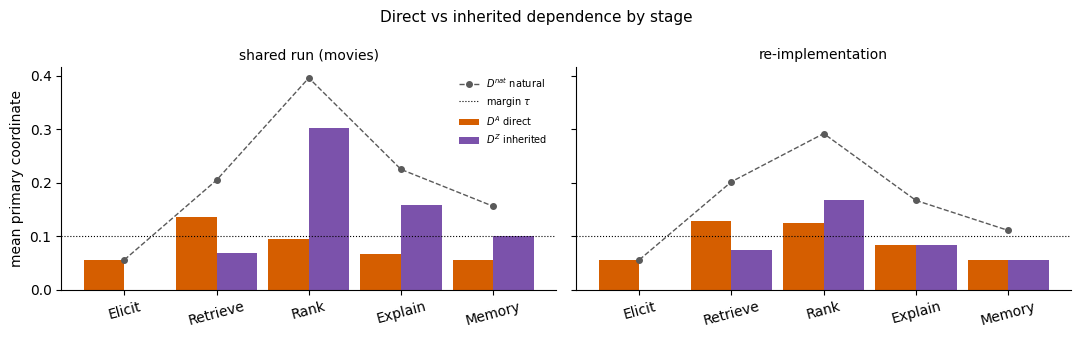

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (frame, title) in zip(axes, [(theirs, "shared run (movies)"),
                                     (mine, "re-implementation")]):
    idx = np.arange(len(STAGES))
    ax.bar(idx - 0.22, frame["direct"], width=0.44, label="$D^A$ direct", color="#D55E00")
    ax.bar(idx + 0.22, frame["inherited"], width=0.44, label="$D^Z$ inherited", color="#7B52AB")
    ax.plot(idx, frame["natural"], "o--", color="#5A5A5A", lw=1, ms=4,
            label="$D^{nat}$ natural")
    ax.axhline(MARGIN, color="black", lw=0.8, ls=":", label=r"margin $\tau$")
    ax.set_xticks(idx)
    ax.set_xticklabels(STAGES, rotation=15)
    ax.set_title(title, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("mean primary coordinate")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Direct vs inherited dependence by stage", fontsize=11)
fig.tight_layout()
plt.show()

Elicit, Retrieve and Rank agree, and the ordering across stages is preserved. Explain and Memory
come out as exact ties here rather than as `inherited`, and the reason is a property of this
re-implementation's design rather than a disagreement: it plants the same number of scenarios at
every stage, so at Explain and Memory the direct channel (own plant) and the inherited channel
(upstream plants reaching them) carry equal weight by construction. The shared run's scenario mix
is not balanced that way, so its Explain and Memory rows tilt inherited. The tie is not evidence
either way, and it is the reason the comparison above prints ties explicitly instead of forcing a
winner.

## 12. Proposed next step, and what is still open

**The proposal from the channel**, in order:

1. Make the planted-sensitivity / localization experiment **completely robust** first.
2. Then move to **two complementary real evaluation settings**: one controlled agentic
   recommendation benchmark with verifiable preferences and constraints, and one more realistic
   conversational or interactive dataset.
3. Keep **Elicit, Retrieve and Rank as the core paper**; hold Explain and Memory as extensions,
   promoted only if their results are strong.

**The empirical story that structure is meant to tell**, which is also the cleanest statement of
the paper's contribution so far:

> observe divergence → identify whether it is direct or inherited → determine whether the
> dependence is prohibited → measure harm when a reference exists → repair the responsible stage
> and test whether downstream disparity disappears.

**What this notebook found that needs attention before step 1 can be called done.** These came
out of the re-implementation, so they are properties of the design rather than of anyone's code:

- **`top1_gap` is the wrong primary coordinate for Rank.** Noise floor 0.328 against a direct
  effect of 0.094 in the shared run (§5), and a missed detection here when a real boost failed to
  flip the top item (§8). It is both noisy and insensitive. Replace it with a graded coordinate
  and the localization claim gets much stronger.
- **The repair experiment cannot score Rank repair on a Rank-based outcome** (§10). Rank's
  removability equals its own `before` value by construction, in both the shared run and here.
  Measure removability strictly downstream of the repaired stage.
- **Localization accuracy should be reported against effect size**, not as a single percentage.
  100% on strong planted faults says little about the weak-effect regime, which is the regime a
  real audit lives in.
- **Corpus-mean diagnoses are not verdicts** (§5). Elicit reads `invariant` on the corpus mean
  while being the planted stage in a sixth of scenarios. Per-scenario diagnosis, corpus-level
  distribution.
- **Some masking is structural, not incidental** (§9). Explain- and Memory-planted faults cannot
  move a single-turn ranking at all. That strengthens the argument for a process-level audit and
  should be stated as a structural claim, not left as an empirical rate.
- **The soundness check that no endpoint difference arises without direct sensitivity** holds in
  the toy pipeline because a planted fault is the only route to a difference. It will not hold
  under a stochastic real agent; the cell should be reported rather than assumed empty.

**Questions for Yashar** (in rough priority order):

1. Is $D_s^{Z}$ intended as a *diagnostic* only, or does it also carry normative weight? A stage
   with $D^A = 0$ and large $D^Z$ is faithful, but it is also the stage where the harm becomes
   visible to the user. Which stage bears responsibility in that case?
2. Which single quantity is eq. 5 of `main_yd.tex` — $D_s^A$, or the pair
   $(D_s^A, D_s^Z)$? The manuscript's notation should match. (The `main_yd.tex` attachment has
   been deleted from the channel; a re-share, or the Overleaf project, would settle it.)
3. For the controlled agentic benchmark in step 2 — is there a preferred one, or is that open?
4. Do the existing $\Delta$ metrics ($\Delta_{\mathrm{burden}}$, $\Delta_{\mathrm{evidence}}$, …)
   survive as the $d_s$ distance functions *inside* the crossover, or are they replaced? They
   compose cleanly as $d_s$, which would preserve the existing metrics section.

## 13. What has to change in the manuscript

Mapping the revision onto the current draft (`paper/fair_trace_acm.tex`), so the edit is
mechanical rather than exploratory:

| section | change |
|---|---|
| Abstract, Intro | reframe from "a delta at each stage" to "where dependence enters"; the deltas become the $d_s$ inside the crossover, not the contribution |
| §3.3 Trajectories and deltas | add the crossover $Y_s^{i,j}$, $D_s^{\mathrm{nat}}$, $D_s^A$, $D_s^Z$ and the diagnosis rule **before** the existing per-stage deltas, which then read as choices of $d_s$ |
| §3.3.2 Invariance/quality benefits | recast: sensitivity is reference-free, quality needs $\Omega_s$, and "not identified" is a legitimate reported verdict |
| §3.4 Evaluation method | add the validity gate, the planted-fault localization protocol, and the repair/removability test as explicit procedure steps |
| §3.4.4 LLM-as-judge | demote from load-bearing to optional-for-semantic-constructs; deterministic checks and task ground truth take precedence |
| §4 Metrics | keep, but relabel the $\Delta$s as distance functions and add the noise coordinate |
| §5–6 Setup / Results | the two toy domains and the four headline results are the first real results the paper has |
| Contributions | replace "localizes where violations are introduced" with the sharper claim: *distinguishes* direct sensitivity from inherited dependence, and validates the distinction against planted faults |